# Task 3: Image Classification with a Pre-trained Model

**Model:** MobileNet V2 (PyTorch, pretrained on ImageNet-1k)  
**Test images:** MNIST digits (already downloaded from Task 8) converted to RGB  
**Goal:** Load a pre-trained model, preprocess images, run inference, and interpret predictions.

**Note:** MNIST digits are out-of-distribution for ImageNet (which has natural photos, not handwritten digits), so we don't expect correct digit labels. The exercise is to understand the full inference pipeline — preprocessing → forward pass → softmax → top-k decoding.

In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.13.0+cpu


## Load Pre-trained MobileNetV2

In [2]:
weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
model = models.mobilenet_v2(weights=weights)
model.eval().to(device)

# class labels and recommended transforms bundled inside the weights object
imagenet_labels = weights.meta['categories']
preprocess = weights.transforms()   # Resize(256) -> CenterCrop(224) -> Normalize

print(f"Model loaded — {len(imagenet_labels)} ImageNet classes")
print(f"Input transform: {preprocess}")

Model loaded — 1000 ImageNet classes
Input transform: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Load MNIST Images (already on disk from Task 8)

In [3]:
# load MNIST without any transform — we want raw PIL images
mnist = datasets.MNIST(root='./data', train=False, download=False)

# pick one clean example per digit class (0-9)
seen, samples = set(), []
for img, label in mnist:
    if label not in seen:
        samples.append((img, label))
        seen.add(label)
    if len(seen) == 10:
        break

print(f"Collected {len(samples)} samples (one per digit)")

Collected 10 samples (one per digit)


## Inference Helper

MobileNetV2 expects 3-channel (RGB) input. MNIST is grayscale — we convert to RGB by repeating the single channel three times.

In [4]:
def classify(pil_img, top_k=5):
    """Classify a PIL image and return top-k (label, probability) pairs."""
    # convert grayscale to RGB — required for the 3-channel model
    rgb_img = pil_img.convert('RGB')
    tensor = preprocess(rgb_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)

    probs = torch.nn.functional.softmax(logits[0], dim=0)
    top_probs, top_idx = torch.topk(probs, top_k)
    return [(imagenet_labels[i], p.item()) for i, p in zip(top_idx, top_probs)]

# run predictions on all 10 samples
results = []
for img, digit in samples:
    preds = classify(img)
    results.append((img, digit, preds))
    top_label, top_conf = preds[0]
    print(f"Digit {digit}: top-1 → '{top_label}' ({top_conf*100:.1f}%)")

Digit 7: top-1 → 'nematode' (22.6%)
Digit 2: top-1 → 'letter opener' (24.8%)
Digit 1: top-1 → 'nematode' (12.5%)


Digit 0: top-1 → 'pick' (5.8%)


Digit 4: top-1 → 'nematode' (15.5%)
Digit 9: top-1 → 'nematode' (24.2%)
Digit 5: top-1 → 'letter opener' (10.6%)
Digit 6: top-1 → 'pick' (46.9%)
Digit 3: top-1 → 'chain' (17.3%)


Digit 8: top-1 → 'pick' (15.3%)


## Visualise Predictions

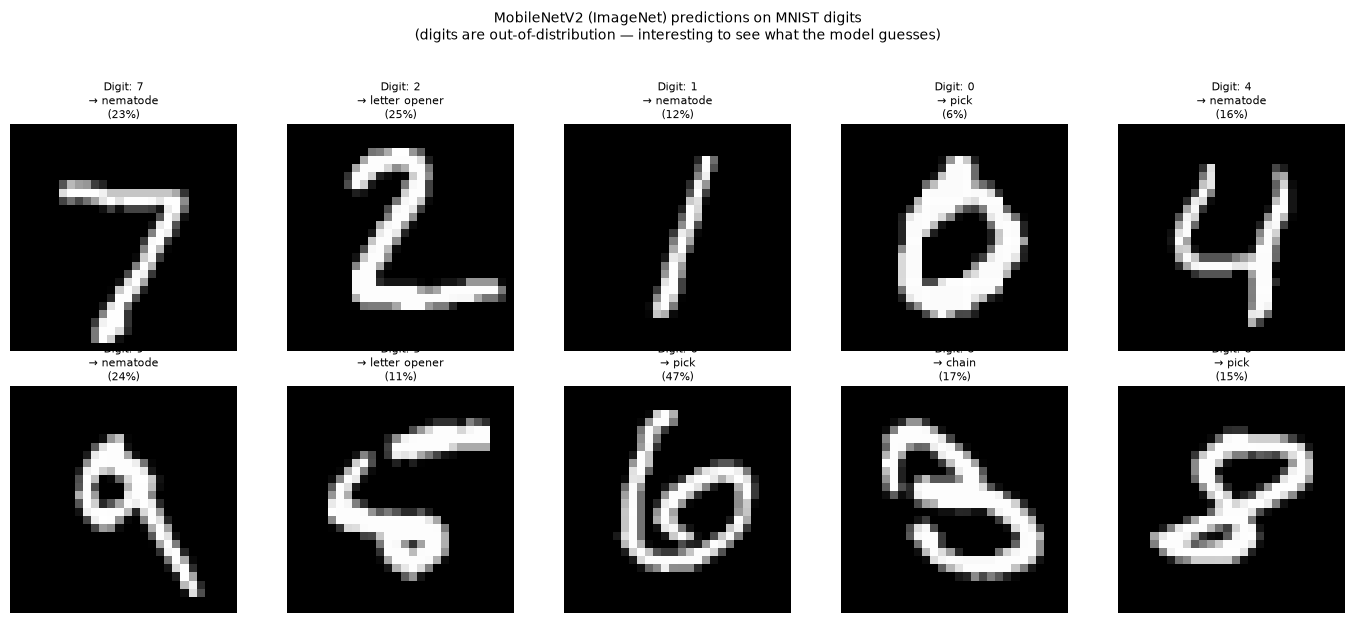

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for ax, (img, digit, preds) in zip(axes.flatten(), results):
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    top_label, top_conf = preds[0]
    short = top_label[:15] + '..' if len(top_label) > 15 else top_label
    ax.set_title(f"Digit: {digit}\n→ {short}\n({top_conf*100:.0f}%)", fontsize=8, pad=4)

plt.suptitle('MobileNetV2 (ImageNet) predictions on MNIST digits\n'
             '(digits are out-of-distribution — interesting to see what the model guesses)',
             fontsize=10, y=1.03)
plt.tight_layout()
plt.savefig('task3_mnist_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

## Top-5 Confidence Detail

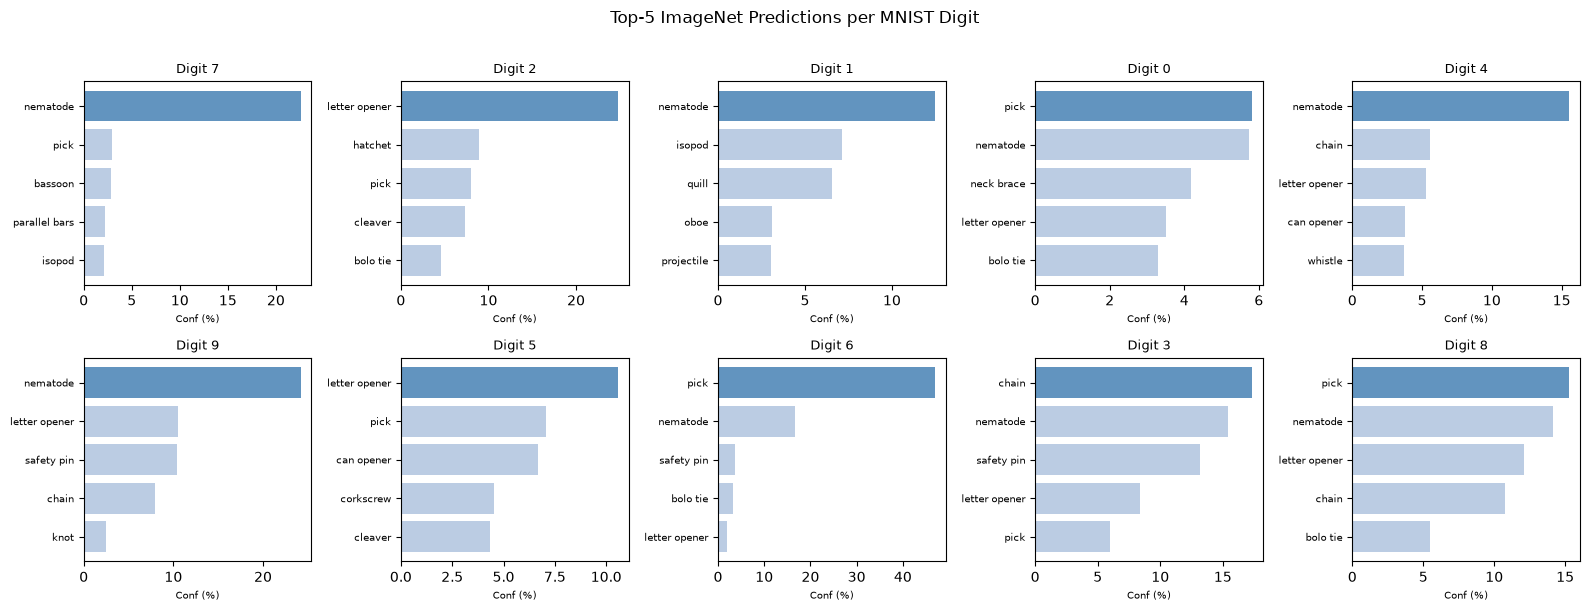

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))

for ax, (img, digit, preds) in zip(axes.flatten(), results):
    labels = [p[0][:18] for p in preds]
    probs  = [p[1]*100 for p in preds]
    colors = ['steelblue'] + ['lightsteelblue'] * (len(preds)-1)
    ax.barh(range(len(preds)), probs[::-1], color=colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(preds)))
    ax.set_yticklabels(labels[::-1], fontsize=7)
    ax.set_title(f'Digit {digit}', fontsize=9)
    ax.set_xlabel('Conf (%)', fontsize=7)

plt.suptitle('Top-5 ImageNet Predictions per MNIST Digit', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('task3_top5.png', dpi=100, bbox_inches='tight')
plt.show()

## Confidence Distribution Across All 10 Digits

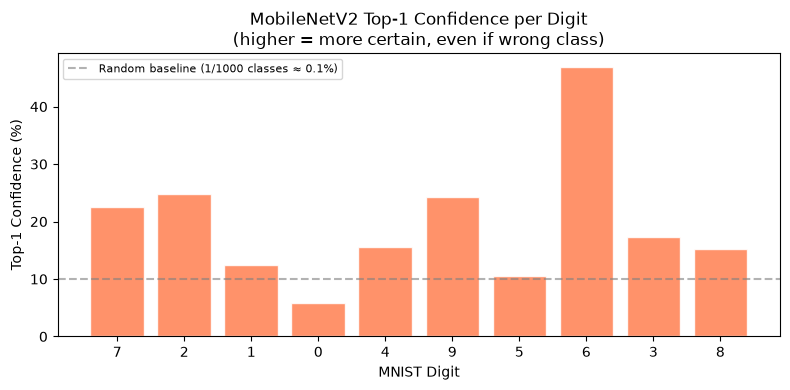

Average top-1 confidence: 19.5%
The model still makes confident predictions even on out-of-distribution inputs —
this is a well-known limitation of softmax classifiers (overconfidence).


In [7]:
top1_confs = [preds[0][1]*100 for _, _, preds in results]
digits = [str(d) for _, d, _ in results]

plt.figure(figsize=(8, 4))
bars = plt.bar(digits, top1_confs, color='coral', alpha=0.85, edgecolor='white')
plt.axhline(10, color='gray', linestyle='--', alpha=0.6, label='Random baseline (1/1000 classes ≈ 0.1%)')
plt.ylabel('Top-1 Confidence (%)')
plt.xlabel('MNIST Digit')
plt.title('MobileNetV2 Top-1 Confidence per Digit\n(higher = more certain, even if wrong class)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('task3_confidence.png', dpi=100)
plt.show()

avg_conf = np.mean(top1_confs)
print(f"Average top-1 confidence: {avg_conf:.1f}%")
print("The model still makes confident predictions even on out-of-distribution inputs —")
print("this is a well-known limitation of softmax classifiers (overconfidence).")

## Summary

- MobileNetV2 (pretrained on ImageNet) correctly handles the full inference pipeline on any image.
- MNIST digits are **out-of-distribution** — the model was never trained on handwritten digits, so its ImageNet class predictions are 'creative' (e.g. a '0' might get predicted as a 'dial telephone' or 'hook').
- Despite being wrong, the model is still **confidently wrong** — this is the **softmax overconfidence** problem, a known limitation.
- For real digit recognition, you'd either fine-tune this model on digit data, or train from scratch on MNIST.
- `weights.transforms()` is the modern torchvision API — it gives you the exact preprocessing the model was trained with.